<a href="https://colab.research.google.com/github/Tweenwrld/Mathematics-of-ML/blob/main/Mathematics_of_machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loading Iris dataset**

In [ ]:
from sklearn.datasets import load_iris
data = load_iris()
X, y = data["data"], data["target"]
X[:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

**Distribution of Features  in our Dataset**

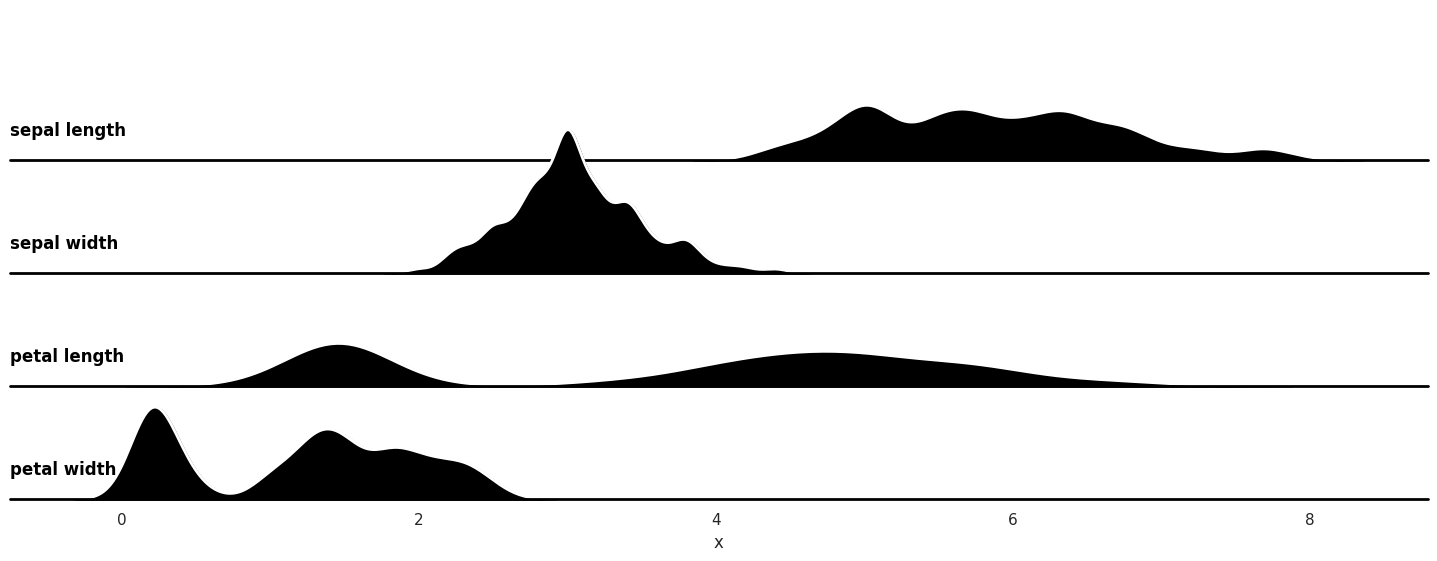

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


sns.set_theme(style="white", rc={"axes.facecolor": (0, 0,0,0)})

# Create the data
x = X.ravel()
labels = ["sepal length", "sepal width", "petal length", "petal width"]
g = np.tile(labels, len(X))
df = pd.DataFrame(dict(x = x, g = g))

# Initialize the facetGrid object
pal= sns.cubehelix_palette(10, rot = -.25, light = -.7)
g = sns.FacetGrid(df, row = "g", hue = "g", aspect = 10, height = 1.5, palette=pal)

# Draw densities
g.map(sns.kdeplot, "x", bw_adjust=.5, clip_on = False, fill = True, alpha = 1, linewidth = 1.5)
g.map(sns.kdeplot, "x", clip_on = False, color = "w", lw = 2, bw_adjust = .5)

# Add reference line
g.refline(y = 0, linewidth = 2, linestyle="-", color = None, clip_on = False)

# Label each plot
g.map(lambda x, color, label: plt.gca().text(0, .2, label, fontweight="bold",
color=color,ha="left", va="center", transform=plt.gca().transAxes), "x")

# Adjust subplots and aesthetics
g.figure.subplots_adjust(hspace=-.25)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.show()

You can see in the figure above that some are more stretched out (like sepal length), while others are narrower
(like sepal width). In practical scenarios, this can hurt the predictive performance of our algorithms.Then the code below transforms the dataset to a more expressive one

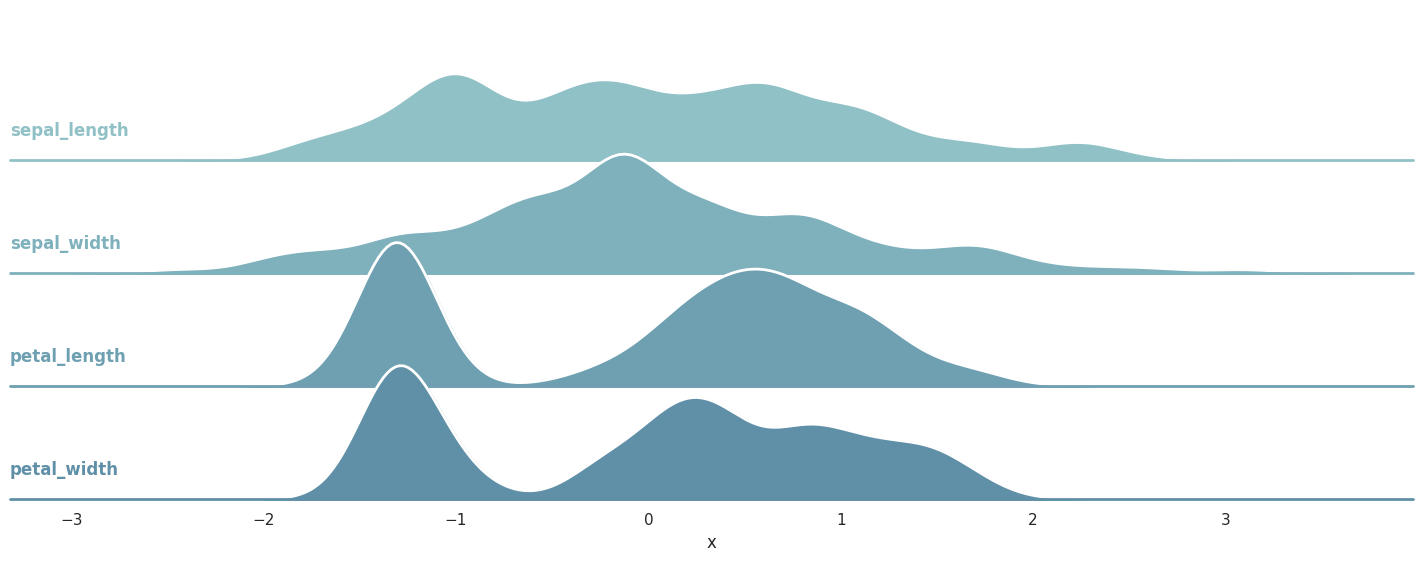

In [ ]:
X_scaled = (X - X.mean(axis=0))/X.std(axis=0)
X_scaled[:10]

# create the data
x = X_scaled.ravel()
labels = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
g = np.tile(labels, X_scaled.shape[0])
df = pd.DataFrame(dict(x=x, g=g))

# Initialize the FaceGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light =.7)
grid = sns.FacetGrid(df, row="g", hue="g", aspect=10, height=1.5, palette=pal)

# Draw the densities
grid.map(sns.kdeplot, "x", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
grid.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Add reference line
grid.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Add labels to each plot
grid.map(lambda x, color, label: plt.gca().text(0, .2, label, fontweight="bold",
color=color,ha="left", va="center", transform=plt.gca().transAxes), "x")

# Adjust subplots and aesthetics
grid.figure.subplots_adjust(hspace=-.25)
grid.set_titles("")
grid.set(yticks=[], ylabel="")
grid.despine(bottom=True, left=True)

plt.show()

# Monte Carlo Integration and Pi Estimation


Classical numerical integration evaluates a function on a fixed grid of points spread
uniformly across the domain. This works fine in 1D or 2D, but in high dimensions the
number of grid points grows exponentially — a grid with 10 points per dimension in
100 dimensions requires $10^{100}$ evaluations. This is computationally impossible.

**Monte Carlo integration only evaluates the function where there is meaningful
probability mass.** By sampling from the distribution rather than covering the whole
space, it scales gracefully to high-dimensional problems. The cost per estimate grows
as $O(N)$ regardless of dimension — the same 10,000 samples work whether the
problem is 2D or 1000D.

## Approximating Expectations
Start with the expected value of some function $f$ of a random variable $Z = f(Y)$:

$$E[f(Y)] = \int f(y)\,p(y)\,dy \approx \frac{1}{S}\sum_{s=1}^{S} f(y_s), \qquad y_s \sim p(y)$$



- $f(Y)$ — the function we care about, applied to a random variable $Y$
- $p(y)$ — the distribution of $Y$, telling us how likely each value is
- $\int f(y)\,p(y)\,dy$ — the true expected value: a weighted average of $f(y)$
  where the weights are $p(y)$
- $\frac{1}{S}\sum_{s=1}^S f(y_s)$ — the Monte Carlo estimate: just draw $S$ samples
  from $p(y)$ and average $f$ over them

By the Law of Large Numbers, the sample average converges to the
true expectation as $S \to \infty$. Each sample $y_s$ drawn from $p(y)$ lands in
high-probability regions more often — exactly where it should be weighted more.

## Extending to Arbitrary Integrals

Now apply the same idea to any integral $I = \int_a^b f(x)\,dx$. Multiply and divide
by the PDF of a uniform distribution $p(x) = \frac{1}{b-a}$ over $(a, b)$:

$$I = \int_a^b f(x)\,dx = \int_a^b \underbrace{f(x)(b-a)}_{w(x)} \cdot \underbrace{\frac{1}{b-a}}_{p(x)}\,dx = E_{p(x)}[w(x)]$$

This rewrites the integral as an expectation under a uniform distribution. The Monte
Carlo estimate follows immediately:

$$I \approx \frac{1}{N}\sum_{i=1}^{N} w(x_i), \qquad x_i \sim \text{Unif}(a, b)$$

where the **scaled function** $w(x) = f(x)(b-a)$ absorbs the width of the interval.

**Every symbol:**
- $p(x) = \frac{1}{b-a}$ — PDF of the uniform distribution over $(a,b)$, constant everywhere
- $w(x) = f(x)(b-a)$ — the function rescaled so that averaging $w(x_i)$ gives $I$ directly
- $x_i \sim \text{Unif}(a,b)$ — sample $N$ points uniformly at random in the interval
- $\frac{1}{N}\sum w(x_i)$ — average the rescaled function values

**In plain English:** Throw darts randomly in the interval, evaluate $w$ at each dart,
and average. The more darts, the better the estimate.

## How Accurate Is the Estimate?

The standard error of the Monte Carlo estimate is:

$$\sigma_{\hat{I}} = \frac{\sigma}{\sqrt{N}}, \qquad \sigma^2 = \frac{1}{N-1}\sum_{i=1}^{N}(f(x_i) - \hat{I})^2$$

Every symbol:
- $\hat{I}$ — our Monte Carlo estimate of the integral
- $\sigma^2$ — empirical variance of the function values $f(x_i)$ around the estimate.
  Measures how much the individual evaluations scatter
- $N$ — number of samples
- $\sigma/\sqrt{N}$ — standard error: how much the estimate itself fluctuates across
  different runs. This is the uncertainty on our estimate of $I$

**Key insight from the $\sqrt{N}$ denominator:**
- To halve the error, you need $4\times$ more samples
- To reduce error by $10\times$, you need $100\times$ more samples
- This $1/\sqrt{N}$ convergence rate is universal — it holds regardless of dimension

**This is both the strength and weakness of Monte Carlo integration:**
- Strength: convergence rate does not depend on dimension
- Weakness: $1/\sqrt{N}$ is slow — you need many samples for high precision

## Estimating $\pi$ via Monte Carlo Integration

### Setting Up the Integral (Equation 2.10)

The area of a circle with radius $r$ is $I = \pi r^2$. We can write this area as a
double integral over the square $[-r, r] \times [-r, r]$:

$$I = \int_{-r}^{r}\int_{-r}^{r} \mathbf{1}[x^2 + y^2 \leq r^2]\,dx\,dy = E_{x,y}[w(x,y)]$$

Every symbol:
- $\mathbf{1}[x^2 + y^2 \leq r^2]$ — **indicator function**: equals 1 if the point $(x,y)$
  is inside the circle of radius $r$, equals 0 if outside. This is the function we integrate.
- $\int_{-r}^{r}\int_{-r}^{r}$ — integrating over the square that contains the circle
- $E_{x,y}[w(x,y)]$ — rewriting as an expectation under the uniform distribution over the square

**Why $\pi = I/r^2$:** Once we estimate $I$ (the area of the circle), we just divide by
$r^2$ to recover $\pi$.

### The Scaled Function $w(x,y)$ (Equation 2.11)

The uniform PDF over the square $[-r,r]\times[-r,r]$ is $p(x,y) = \frac{1}{(2r)^2}$.
Applying the same reweighting as before:

$$w(x,y) = (b_x - a_x)(b_y - a_y)\cdot\mathbf{1}[x^2+y^2\leq r^2] = (2r)(2r)\cdot\mathbf{1}[x^2+y^2\leq r^2] = 4r^2\cdot\mathbf{1}[x^2+y^2\leq r^2]$$

**In plain English:** For each random point $(x,y)$ drawn uniformly from the square,
$w(x,y) = 4r^2$ if the point is inside the circle, and $0$ if it is outside. Averaging
$w$ over many points gives the area of the circle.

The Monte Carlo estimate:

$$\hat{I} = \frac{1}{N}\sum_{i=1}^{N}(2r)^2\cdot\mathbf{1}[x_i^2 + y_i^2 \leq r^2], \qquad (x_i, y_i) \sim \text{Unif}([-r,r]^2)$$

$$\hat{\pi} = \frac{\hat{I}}{r^2} = \frac{4}{N}\sum_{i=1}^{N}\mathbf{1}[x_i^2 + y_i^2 \leq r^2]$$

**Geometric interpretation:** The fraction of random points falling inside the circle
equals (area of circle)/(area of square) $= \pi r^2 / 4r^2 = \pi/4$. Multiply by 4 to
get $\pi$. This is the famous "dartboard" method for estimating $\pi$.


**In the code:**
- `inside = R2 < radius**2` — Boolean array, True for points inside the circle
- `samples = (2*radius)**2 * inside` — $w(x_i, y_i)$: either $4r^2$ or $0$
- `I_hat = np.mean(samples)` — Monte Carlo estimate of the area $\hat{I}$
- `pi_hat = I_hat / radius**2` — recover $\hat{\pi}$ from $\hat{I}$
- `pi_hat_se = np.std(samples)/np.sqrt(num_iter)` — standard error $\sigma/\sqrt{N}$

**Output:** Running with $N = 10{,}000$ gives $\hat{\pi} = 3.1348 \pm 0.0164$.
The true value $\pi = 3.14159\ldots$ falls well within the error bounds.

## Understanding the Result

The scatter plot shows two groups of points:
- **Blue points** — samples inside the circle ($x^2 + y^2 \leq r^2$). These are
  "accepted" and contribute $(2r)^2$ to the integral estimate.
- **Red points** — samples outside the circle ($x^2 + y^2 > r^2$). These are
  "rejected" and contribute $0$.

The fraction of blue points approximates $\pi/4$. With $N=10{,}000$ samples the
blue region visually traces the circle boundary clearly. With fewer samples (say $N=100$),
the boundary looks jagged and the estimate is poor. With more samples (say $N=10^6$),
the estimate is excellent but computationally more expensive.

## Convergence: How Fast Does It Work?

| Samples $N$ | Expected error $\sigma/\sqrt{N}$ | Typical $\hat{\pi}$ |
|---|---|---|
| 100 | ~0.16 | 3.00 – 3.28 |
| 1,000 | ~0.05 | 3.09 – 3.19 |
| 10,000 | ~0.016 | 3.125 – 3.158 |
| 100,000 | ~0.005 | 3.136 – 3.147 |
| 1,000,000 | ~0.0016 | 3.1400 – 3.1432 |

The error shrinks at rate $1/\sqrt{N}$ — halving the error requires $4\times$ more samples.
This is the fundamental tradeoff of Monte Carlo methods: unbiased, dimension-free,
but slow to converge.




pi est: 3.1348 +/- 0.016469


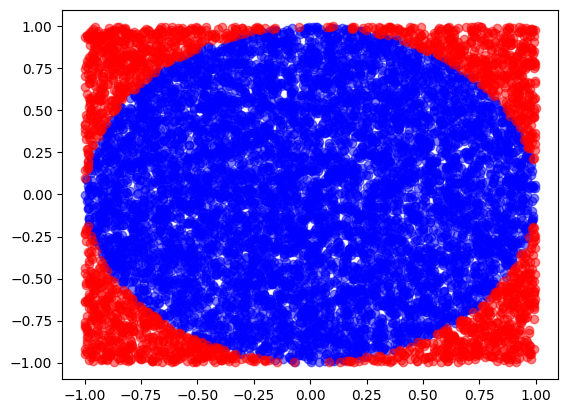

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def pi_est(radius=1, num_iter=int(1e4)):

  X = np.random.uniform(-radius,+radius,num_iter)
  Y = np.random.uniform(-radius,+radius,num_iter)

  R2 = X**2 + Y**2
  inside = R2 < radius**2
  outside = ~inside

  samples = (2*radius)*(2*radius)*inside

  I_hat = np.mean(samples)
  pi_hat = I_hat/radius ** 2
  pi_hat_se = np.std(samples)/np.sqrt(num_iter)
  print("pi est: {} +/- {:f}".format(pi_hat, pi_hat_se))

  plt.figure()
  plt.scatter(X[inside],Y[inside], c='b', alpha=0.5)
  plt.scatter(X[outside],Y[outside], c='r', alpha=0.5)
  plt.show()

if __name__ == "__main__":

  pi_est()

## **Bionomial Stock Price simulation**



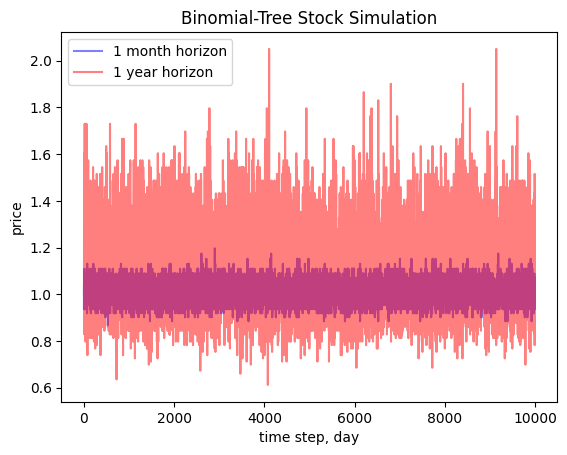

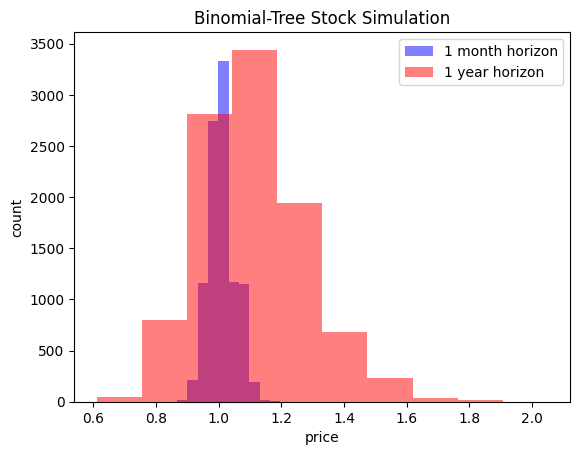

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(42)
def binomial_tree(mu, sigma, S0, N, T, step):

  #compute state price and probability

  u = np.exp(sigma * np.sqrt(step)) # Up-price
  d = 1.0/u # Down-state Price
  p = 0.5+0.5*(mu/sigma)*np.sqrt(step) # up-state transition probability

  #binomial tree simulation
  up_times = np.zeros((N, len(T)))
  down_times = np.zeros((N, len(T)))
  for idx in range(len(T)):
    up_times[:,idx] = np.random.binomial(T[idx]/step, p, N)
    down_times[:,idx] = T[idx]/step - up_times[:,idx]

  #compute terminal price
  ST = S0 * u**up_times * d**down_times

  #generate plots
  plt.figure()
  plt.plot(ST[:,0], color='b', alpha=0.5, label='1 month horizon')
  plt.plot(ST[:,1], color='r', alpha=0.5, label='1 year horizon')
  plt.xlabel('time step, day')
  plt.ylabel('price')
  plt.title('Binomial-Tree Stock Simulation')
  plt.legend()
  plt.show()

  plt.figure()
  plt.hist(ST[:,0], color='b', alpha=0.5, label='1 month horizon')
  plt.hist(ST[:,1], color='r', alpha=0.5, label='1 year horizon')
  plt.xlabel('price')
  plt.ylabel('count')
  plt.title('Binomial-Tree Stock Simulation')
  plt.legend()
  plt.show()
if __name__ == "__main__":

  #model parameters
  mu = 0.1 # Mean
  sigma = 0.15
  S0 = 1 # Starting price

  N = 10000 #Number of simulations
  T = [21.0/252, 1.0] # Time horizon, in years
  step = 1.0/252 # Time step, in years

  binomial_tree(mu, sigma, S0, N, T, step)

**Self-avoiding random walk**

iter: 0, trial 0
iter: 0, trial 1
iter: 0, trial 2
iter: 0, trial 3
iter: 0, trial 4
iter: 0, trial 5
iter: 0, trial 6
iter: 0, trial 7
iter: 0, trial 8
iter: 0, trial 9
iter: 0, trial 10
iter: 0, trial 11
iter: 0, trial 12
iter: 0, trial 13
iter: 0, trial 14
iter: 0, trial 15
iter: 0, trial 16
iter: 0, trial 17
iter: 0, trial 18
iter: 0, trial 19
iter: 0, trial 20
iter: 0, trial 21
iter: 0, trial 22
iter: 0, trial 23
iter: 0, trial 24
iter: 0, trial 25
iter: 0, trial 26
iter: 0, trial 27
iter: 0, trial 28
iter: 0, trial 29
iter: 0, trial 30
iter: 0, trial 31
iter: 0, trial 32
iter: 0, trial 33
iter: 0, trial 34
iter: 0, trial 35
iter: 0, trial 36
iter: 0, trial 37
iter: 0, trial 38
iter: 0, trial 39
iter: 0, trial 40
iter: 0, trial 41
iter: 0, trial 42
iter: 0, trial 43
iter: 0, trial 44
iter: 0, trial 45
iter: 0, trial 46
iter: 0, trial 47
iter: 0, trial 48
iter: 0, trial 49
iter: 0, trial 50
iter: 0, trial 51
iter: 0, trial 52
iter: 0, trial 53
iter: 1, trial 0
iter: 1, trial 1
iter

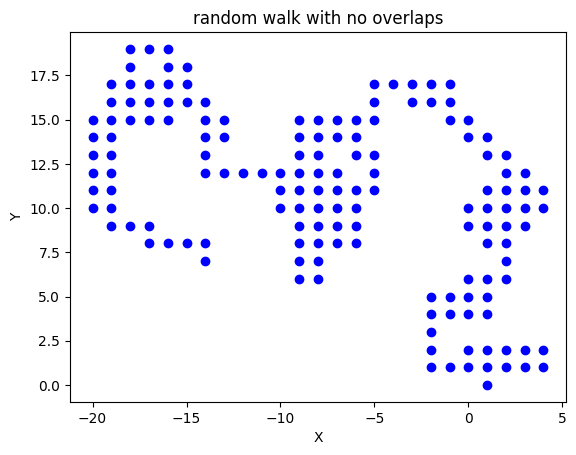

<Figure size 640x480 with 0 Axes>

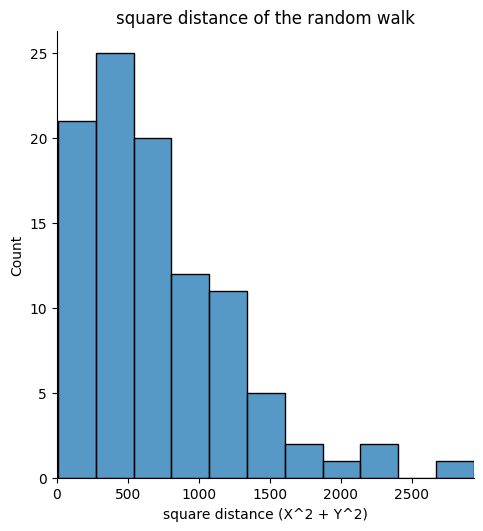

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

def rand_walk(num_step, num_iter, moves):

  #random walk stats
  square_dist = np.zeros(num_iter)
  weights = np.zeros(num_iter)

  for it in range(num_iter):

    trial = 0
    i = 1
    while i != num_step-1:

      #init
      X, Y = 0, 0
      weight = 1
      lattice = np.zeros((2*num_step+1, 2*num_step+1))
      lattice[num_step+1,num_step+1] = 1
      path = np.array([0, 0])
      xx = num_step + 1 + X
      yy = num_step + 1 + Y
      print("iter: %d, trial %d" %(it, trial))

      for i in range(num_step):

        up = lattice[xx,yy+1]
        down = lattice[xx,yy-1]
        left = lattice[xx-1,yy]
        right = lattice[xx+1,yy]
        neighbors = np.array([1, 1, 1, 1]) - np.array([up, down, left, right]) # Computes available directions

        # Avoids self-loops
        if (np.sum(neighbors) == 0):
          i = 1
          break
          #end if
        weight = weight * np.sum(neighbors) #Computes importance weights

        direction = np.where(np.random.rand() < np.cumsum(neighbors/float(sum(neighbors)))) # Samples a move direction

        X = X + moves[direction[0][0],0]
        Y = Y + moves[direction[0][0],1]

        path_new = np.array([X,Y])
        path = np.vstack((path,path_new)) # Stores a sampled path

        #update grid coordinates
        xx = num_step + 1 + X
        yy = num_step + 1 + Y
        lattice[xx,yy] = 1
      #end for
      trial = trial + 1

    #end while
    square_dist[it] = X**2 + Y**2

    weights[it] = weight

  #end for
  mean_square_dist = np.mean(weights * square_dist)/np.mean(weights)
  print("mean square dist: ", mean_square_dist)
  #generate plots
  plt.figure()
  for i in range(num_step-1):
    plt.plot(path[i,0], path[i,1], path[i+1,0], path[i+1,1], 'ob')
  plt.title('random walk with no overlaps')
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.show()
  plt.figure()
  sns.displot(square_dist)
  plt.xlim(0,np.max(square_dist))
  plt.title('square distance of the random walk')
  plt.xlabel('square distance (X^2 + Y^2)')
  plt.show()
if __name__ == "__main__":

  # Number of steps in a random walk
  num_step = 150
  # Number of iterations for averaging results
  num_iter = 100
  # 2D moves
  moves = np.array([[0, 1],[0, -1],[-1, 0],[1, 0]])

  rand_walk(num_step, num_iter, moves)



# Gibbs Sampling for Multivariate Gaussians

**Gibbs sampling** is a Markov Chain Monte Carlo (MCMC) method used to draw samples from complex joint distributions by iteratively sampling one variable at a time from its conditional distribution. For multivariate Gaussian distributions, this process becomes analytically elegant because all conditional distributions are themselves Gaussian.

Mathematical Setup

We consider a
𝑑
-dimensional Gaussian random vector:

𝑋=( 𝑋1, 𝑋2, …, 𝑋𝑑 )𝑇 ∼ 𝑁 ( 𝜇, Σ) where:

𝜇 ∈ 𝑅𝑑  is the mean vector

Σ ∈ 𝑅𝑑 × 𝑑 is the covariance matrix

Σ is symmetric and positive definite

To perform Gibbs sampling, we repeatedly sample:

𝑋𝑖 ( 𝑡 + 1) ∼ 𝑝 (𝑋𝑖 ∣ 𝑋 − 𝑖( 𝑡 ))

where:

𝑋 − 𝑖 denotes all variables except
𝑋𝑡 is the iteration index

### Gaussian Conditional Formula
Partition the variables into two sets:

𝐴 : the variable(s) we want to sample

𝐵 : all remaining variables

Partition the mean and covariance accordingly:

𝜇 = [ 𝜇 𝐴 𝜇 𝐵 ] , Σ = [ Σ 𝐴𝐴 Σ𝐴𝐵 Σ𝐵𝐴 Σ𝐵𝐵]

Then the conditional distribution is:

𝑋𝐴 ∣ 𝑋𝐵 = 𝑥𝐵 ∼ 𝑁 ( 𝜇𝐴 ∣ 𝐵, Σ𝐴 ∣ 𝐵)

with:

𝜇𝐴 ∣ 𝐵 = 𝜇𝐴 + Σ𝐴𝐵 Σ^-1 𝐵𝐵

(𝑥𝐵 − 𝜇𝐵) Σ𝐴 ∣ 𝐵 = Σ𝐴𝐴 Σ𝐴𝐵 Σ^-1 𝐵𝐵 Σ𝐵𝐴

In the 2‑dimensional case, this reduces to simple scalar formulas.

### Gibbs Sampling Procedure
1: Start with an initial vector
𝑥(0).

2: For each dimension 𝑖 :

*   Treat 𝑖 as set 𝐴
*   Compute the conditional mean and variance
*   Sample a new value for 𝑥𝑖
*   Treat all other dimensions as set 𝐵

3: Repeat for the desired number of iterations.

After a burn‑in period, the samples approximate the true joint distribution.

Gibbs sampling is foundational in:

*   Bayesian inference

Posterior sampling in hierarchical models, Bayesian regression, etc.
*   Probabilistic graphical models

Markov Random Fields, Bayesian Networks, and topic models (e.g., LDA).



*   Generative modeling

Gibbs sampling is the conceptual ancestor of autoregressive models and diffusion models, where sampling proceeds dimension‑by‑dimension or timestep‑by‑timestep.

*   High‑dimensional uncertainty quantification

Gaussian conditionals allow efficient sampling in large latent spaces.



This code demonstrates Gibbs sampling: a multivariate Gaussian where all conditionals are analytically tractable.

It Produces

*   Gibbs samples from the target Gaussian

*   Ground truth samples from SciPy’s multivariate normal
*   A visual comparison showing that Gibbs sampling converges to the true distribution after burn‑in



This validates the correctness of the sampler and illustrates how MCMC approximates complex distributions through iterative conditional sampling.

## 1. The Math Behind Conditional Gaussian Formulas

Given a joint multivariate Gaussian $p(\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, we partition $\mathbf{x}$ into two parts: $\mathbf{x}_A$ (variables we want) and $\mathbf{x}_B$ (variables we condition on):

$$\mathbf{x} = \begin{pmatrix} \mathbf{x}_A \\ \mathbf{x}_B \end{pmatrix}, \quad \boldsymbol{\mu} = \begin{pmatrix} \boldsymbol{\mu}_A \\ \boldsymbol{\mu}_B \end{pmatrix}, \quad \boldsymbol{\Sigma} = \begin{pmatrix} \boldsymbol{\Sigma}_{AA} & \boldsymbol{\Sigma}_{AB} \\ \boldsymbol{\Sigma}_{BA} & \boldsymbol{\Sigma}_{BB} \end{pmatrix}$$

**Key fact:** Any conditional of a multivariate Gaussian is also Gaussian. The conditional mean and covariance are:

$$\boldsymbol{\mu}_{A|B} = \boldsymbol{\mu}_A + \boldsymbol{\Sigma}_{AB} \boldsymbol{\Sigma}_{BB}^{-1} (\mathbf{x}_B - \boldsymbol{\mu}_B)$$

$$\boldsymbol{\Sigma}_{A|B} = \boldsymbol{\Sigma}_{AA} - \boldsymbol{\Sigma}_{AB} \boldsymbol{\Sigma}_{BB}^{-1} \boldsymbol{\Sigma}_{BA}$$

**Intuition:**
- The correction term $\boldsymbol{\Sigma}_{AB} \boldsymbol{\Sigma}_{BB}^{-1} (\mathbf{x}_B - \boldsymbol{\mu}_B)$ adjusts the mean of $\mathbf{x}_A$ based on how far $\mathbf{x}_B$ is from its expected value, scaled by their correlation.
- The conditional covariance is always smaller than $\boldsymbol{\Sigma}_{AA}$ because observing $\mathbf{x}_B$ reduces our uncertainty about $\mathbf{x}_A$.

**Concrete 2D Example:** With $\boldsymbol{\mu} = [1, 1]$ and $\boldsymbol{\Sigma} = \begin{pmatrix} 2 & 1 \\ 1 & 1 \end{pmatrix}$, sampling $x_0$ given $x_1$ gives:

$$\mu_{0|1} = 1 + \frac{1}{1}(x_1 - 1) = x_1, \qquad \sigma^2_{0|1} = 2 - \frac{1}{1} \cdot 1 = 1$$

So the conditional is simply $\mathcal{N}(x_1, 1)$.

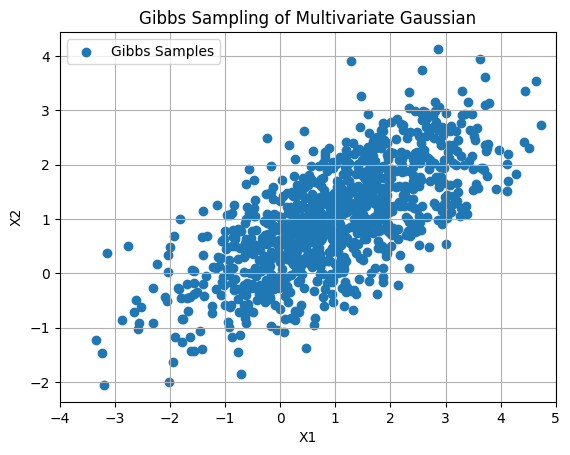

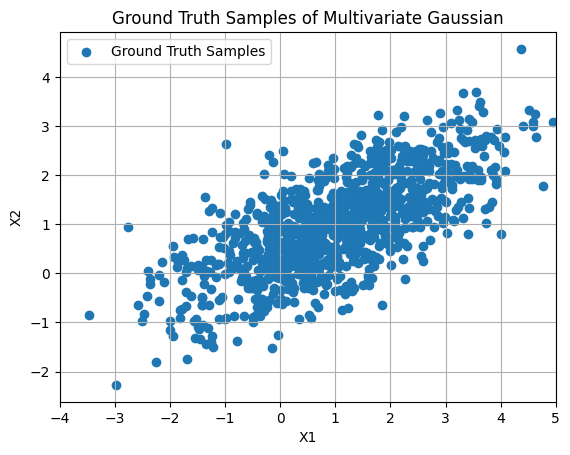

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from numpy.linalg import inv
from scipy.stats import multivariate_normal

np.random.seed(42)

class gibbs_gauss:

  # Computes P(X_A | X_B = x) = N(mu_{A|B}, Sigma_{A|B})
  def gauss_conditional(self, mu, Sigma, setA, x):
    dim = len(mu)
    setU = set (range(dim))
    setB = setU.difference(setA)
    muA = np.array([mu[item] for item in setA]).reshape(-1,1)
    muB = np.array([mu[item] for item in setB]).reshape(-1,1)
    xB = np.array([x[item] for item in setB]).reshape(-1,1)

    Sigma_AA = []
    for (idx1, idx2) in itertools.product(setA, setA):
      Sigma_AA.append(Sigma[idx1][idx2])
    Sigma_AA = np.array(Sigma_AA).reshape(len(setA),len(setA))

    Sigma_AB = []
    for (idx1, idx2) in itertools.product(setA, setB):
      Sigma_AB.append(Sigma[idx1][idx2])
    Sigma_AB = np.array(Sigma_AB).reshape(len(setA),len(setB))

    Sigma_BB = []
    for (idx1, idx2) in itertools.product(setB, setB):
      Sigma_BB.append(Sigma[idx1][idx2])
    Sigma_BB = np.array(Sigma_BB).reshape(len(setB),len(setB))

    Sigma_BB_inv = inv(Sigma_BB)
    mu_AgivenB = muA + np.matmul(np.matmul(Sigma_AB, Sigma_BB_inv), xB - muB)
    Sigma_AgivenB = Sigma_AA - np.matmul(np.matmul(Sigma_AB, Sigma_BB_inv), np.transpose(Sigma_AB))

    return mu_AgivenB, Sigma_AgivenB

  def sample(self, mu, Sigma, xinit, num_samples):
    dim = len(mu)
    samples = np.zeros((num_samples, dim))
    x = xinit
    for s in range(num_samples):
      for d in range(dim):
        mu_AgivenB, Sigma_AgivenB = self.gauss_conditional(mu, Sigma, set([d]), x)
        x[d] = np.random.normal(mu_AgivenB, np.sqrt(Sigma_AgivenB))
      #end for
      samples[s,:] = np.transpose(x)
    #end for
    return samples

if __name__ == "__main__":

  num_samples = 2000
  mu = [1, 1]
  Sigma = [[2,1], [1,1]]
  xinit = np.random.rand(len(mu),1)
  num_burnin = 1000
  gg = gibbs_gauss()
  gibbs_samples = gg.sample(mu, Sigma, xinit, num_samples)
  scipy_samples = multivariate_normal.rvs(mean=mu,cov=Sigma,size=num_samples,random_state=42)
  plt.figure()
  plt.scatter(gibbs_samples[num_burnin:,0], gibbs_samples[num_burnin:,1], label='Gibbs Samples')
  plt.grid(True); plt.legend(); plt.xlim([-4,5])
  plt.title("Gibbs Sampling of Multivariate Gaussian"); plt.xlabel("X1"); plt.ylabel("X2")
  plt.show()
  plt.figure()
  plt.scatter(scipy_samples[num_burnin:,0], scipy_samples[num_burnin:,1], label='Ground Truth Samples')
  plt.grid(True); plt.legend(); plt.xlim([-4,5])
  plt.title("Ground Truth Samples of Multivariate Gaussian"); plt.xlabel("X1");
  plt.ylabel("X2")
  plt.show()


# Metropolis-Hastings Sampling

While Gibbs Sampling works by drawing directly from exact conditional distributions,
Metropolis-Hastings (MH) is a more general MCMC algorithm that works for virtually
any target distribution — even when we cannot sample from it directly.

The goal remains the same: construct a Markov chain whose stationary distribution
equals our target distribution $p(x)$, which is typically a posterior $p(\theta | x)$
or an unnormalized density $p(\theta)$.

## 1. The Idea: Propose, Then Accept or Reject

At each step, MH does two things:

**Step 1 — Propose:** Draw a candidate new state $x'$ from a proposal distribution $q(x'|x)$,
conditioned on the current state $x$.

**Step 2 — Accept or Reject:** Decide whether to move to $x'$ or stay at $x$, using the
Metropolis-Hastings ratio:

$$r(x'|x) = \min\left(1, \frac{p(x') \, q(x|x')}{p(x) \, q(x'|x)}\right)$$

- Draw $u \sim \text{Uniform}(0, 1)$
- If $u \leq r$: **accept** — move to $x'$
- If $u > r$: **reject** — stay at $x$

**Why this:** The acceptance rule enforces **detailed balance**, which guarantees
that the chain's stationary distribution is exactly $p(x)$. Detailed balance means the
probability of transitioning out of state $x$ equals the probability of transitioning into it —
ensuring the chain does not drift away from the target.

**Important practical advantage:** To compute the MH ratio, we only need $p(x)$ up to
a normalizing constant, because the normalization constants $Z$ appear in both the
numerator and denominator and cancel out. This makes MH applicable to Bayesian
posteriors where the normalizing constant is intractable.

## 2. The Target and Proposal Distributions

In this implementation, we sample from a **mixture of two 2D Gaussians** as our target:

$$p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \, ; \, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

With the following parameters:
- $\boldsymbol{\mu}_1 = [4, 0]$, $\boldsymbol{\Sigma}_1 = \begin{pmatrix} 2 & 1 \\ 1 & 1 \end{pmatrix}$, $\pi_1 = 0.4$
- $\boldsymbol{\mu}_2 = [-4, 0]$, $\boldsymbol{\Sigma}_2 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$, $\pi_2 = 0.6$

For the **proposal distribution**, we use a symmetric Gaussian centered on the current state:

$$q(x'|x) = \mathcal{N}(x' \, ; \, x, \boldsymbol{\Sigma}_{\text{proposal}})$$

This is called the **Random Walk Metropolis** algorithm — the chain explores the space
by taking random steps from wherever it currently is.

**Why:** Because $q(x'|x) = q(x|x')$ for a symmetric
Gaussian, the proposal terms cancel in the MH ratio, simplifying it to:

$$r(x'|x) = \min\left(1, \frac{p(x')}{p(x)}\right)$$

The chain moves to the new state if it has higher probability, and moves to it with
some chance even if it has lower probability — this is what allows the chain to escape
local modes and explore the full distribution.

## 3. The Acceptance Rate: A Diagnostic for Proposal Quality

After running the chain, we compute:

$$\text{Acceptance Rate} = \frac{\text{Number of accepted proposals}}{\text{Total number of proposals}}$$

The acceptance rate is a direct indicator of how well-tuned the proposal distribution is:

| Acceptance Rate | Interpretation |
|---|---|
| **Too low (< 10%)** | Proposal variance is too large — most proposals land in low-probability regions and get rejected. The chain barely moves. |
| **Too high (> 90%)** | Proposal variance is too small — almost every proposal is accepted, but the chain takes tiny steps and explores very slowly. |
| **Roughly 20–50%** | Generally considered a healthy range for good mixing and efficient exploration. |

**Intuition:** Think of the proposal as the size of the steps you take while hiking across a
probability landscape. Steps that are too large send you off cliffs (rejection). Steps that are
too small keep you in the same spot forever. A good step size covers meaningful ground
while staying on solid terrain.

## 4. Random Walk Metropolis vs. Independence Sampler

There are two notable special cases of the MH algorithm based on the choice of proposal:

**Random Walk Metropolis** (used here):
$$q(x'|x) = \mathcal{N}(x' \, ; \, x, \boldsymbol{\Sigma})$$
The proposed state depends on the current state. The chain explores by drifting through
the space step by step.

**Independence Sampler:**
$$q(x'|x) = q(x')$$
The proposed state is drawn independently of the current state. This is similar to
importance sampling — proposals come from a fixed distribution regardless of where
the chain currently is.

## 5. Connection Back to Gibbs Sampling

Recall from the previous section that Gibbs Sampling always accepts every proposal
because it draws directly from the exact full conditional distribution. This means:

$$r_{\text{Gibbs}}(x'|x) = 1 \quad \text{always}$$

This reveals that **Gibbs Sampling is a special case of Metropolis-Hastings** — one
where the proposal is so perfectly chosen (the exact conditional) that no sample is ever
rejected. MH generalizes this by allowing any proposal, at the cost of sometimes
rejecting moves. The more flexible the proposal, the more broadly applicable the
algorithm — but the harder it becomes to tune for efficiency.

MH acceptance ratio:  0.1586


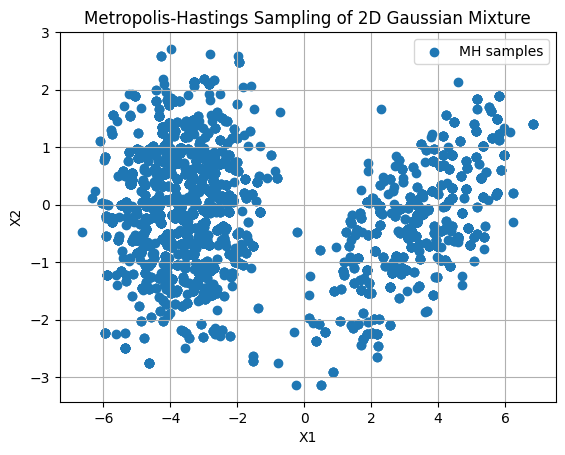

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import uniform
from scipy.stats import multivariate_normal

np.random.seed(42)

class mh_gauss:

  def __init__(self, dim, K, num_samples, target_mu, target_sigma, target_pi, proposal_mu, proposal_sigma):

    # Target parameters:p(x) = \sum_k pi(k) N(x; mu_k, Sigma_k)
    self.dim = dim
    self.K = K
    self.num_samples = num_samples
    self.target_mu = target_mu
    self.target_sigma = target_sigma
    self.target_pi = target_pi

    # Proposal parameters:q(x) = N(x; mu, Sigma)
    self.proposal_mu = proposal_mu
    self.proposal_sigma = proposal_sigma

    # Sampling chain params
    self.n_accept = 0
    self.alpha = np.zeros(self.num_samples)
    self.mh_samples = np.zeros((self.num_samples, self.dim))

  # Target pdf: p(x) = \sum_k pi(k) N(x; mu_k,Sigma_k)
  def target_pdf(self, x):
    prob = 0
    for k in range(self.K):
      prob += self.target_pi[k]*\
      multivariate_normal.pdf(x,self.target_mu[:,k],self.target_sigma[:,:,k])

    #end for
    return prob

  def proposal_pdf(self, x):
    # Proposal pdf:q(x) = N(x; mu, Sigma)
    return multivariate_normal.pdf(x, self.proposal_mu, self.proposal_sigma)

  def sample(self):
    # Draws the initial sample from the proposal.
    x_init = multivariate_normal.rvs(self.proposal_mu, self.proposal_sigma, 1)
    self.mh_samples[0,:] = x_init
    for i in range(self.num_samples-1):
      x_curr = self.mh_samples[i,:]

      x_new = multivariate_normal.rvs(x_curr, self.proposal_sigma, 1)

      # MH Ratio
      self.alpha[i] = (self.proposal_pdf(x_new) / self.proposal_pdf(x_curr)) * \
                (self.target_pdf(x_new) / self.target_pdf(x_curr))

      # MH acceptance probability
      r = min(1, self.alpha[i])
      u = uniform.rvs(loc=0, scale=1, size=1)
      if (u <= r):
        self.n_accept += 1
        # Accept
        self.mh_samples[i+1,:] = x_new

      else:
        # Reject
        self.mh_samples[i+1,:] = x_curr

    #end for
    print("MH acceptance ratio: ", self.n_accept/float(self.num_samples))

if __name__ == "__main__":
  dim = 2
  K = 2
  num_samples = 5000
  target_mu = np.zeros((dim, K))
  target_mu[:,0] = [4,0]
  target_mu[:,1] = [-4,0]
  target_sigma = np.zeros((dim, dim, K))
  target_sigma[:,:,0] = [[2,1],[1,1]]
  target_sigma[:,:,1] = [[1,0],[0,1]]
  target_pi = np.array([0.4, 0.6])
  proposal_mu = np.zeros((dim,1)).flatten()
  proposal_sigma = 10*np.eye(dim)
  mhg = mh_gauss(dim, K, num_samples, target_mu, target_sigma, target_pi, proposal_mu, proposal_sigma)
  mhg.sample()
  plt.figure()
  plt.scatter(mhg.mh_samples[:,0], mhg.mh_samples[:,1], label='MH samples')
  plt.grid(True); plt.legend()
  plt.title("Metropolis-Hastings Sampling of 2D Gaussian Mixture")
  plt.xlabel("X1"); plt.ylabel("X2")
  plt.show()

# Importance Sampling

In Bayesian inference and machine learning, we frequently need to compute expectations of the form:

$$E[f(x)] = \int f(x)\, p(x)\, dx$$

This integral is almost never analytically tractable for interesting distributions. The naive Monte Carlo solution is to sample $x_i \sim p(x)$ directly and average $f(x_i)$. But this fails when:
- $p(x)$ is unnormalized — we only know $\tilde{p}(x)$, not $p(x) = \tilde{p}(x)/Z$
- $p(x)$ has no closed-form sampler
- $p(x)$ is concentrated in a small region that blind sampling will rarely visit

Importance Sampling solves all three problems at once by drawing samples from an easier proposal distribution $q(x)$ and correcting for the mismatch.

## Change of Measure

We multiply and divide by a proposal distribution $q(x)$ that we *can* sample from:

$$E[f(x)] = \int f(x)\, p(x)\, dx = \int f(x)\, \frac{p(x)}{q(x)}\, q(x)\, dx = E_q\!\left[f(x)\, \frac{p(x)}{q(x)}\right]$$

This is a **change of measure** — we rewrite an expectation under $p$ as an expectation under $q$. The correction factor that accounts for the mismatch between the two distributions is the **importance weight**:

$$w(x) = \frac{p(x)}{q(x)}$$

The Monte Carlo estimate then becomes:

$$E[f(x)] \approx \frac{1}{N} \sum_{i=1}^{N} w(x_i)\, f(x_i), \qquad x_i \sim q(x)$$

**Intuition:** Samples drawn from $q$ in regions where $p$ is much larger than $q$ get upweighted — they were underrepresented. Samples in regions where $p$ is much smaller than $q$ get downweighted — they were overrepresented. The weights correct for the bias introduced by sampling from the wrong distribution. The key requirement is that $q(x) > 0$ wherever $p(x) > 0$, so that no region of $p$ is completely missed.

## The Unnormalized Case

In practice, we often only have access to unnormalized distributions $\tilde{p}(x)$ and $\tilde{q}(x)$:

$$p(x) = \frac{\tilde{p}(x)}{Z_p}, \qquad q(x) = \frac{\tilde{q}(x)}{Z_q}$$

The unnormalized importance weight is $\tilde{w}(x) = \tilde{p}(x)/\tilde{q}(x)$. Starting from the expectation and substituting:

$$E[f(x)] = \frac{Z_q}{Z_p} \int f(x)\, \frac{\tilde{p}(x)}{\tilde{q}(x)}\, q(x)\, dx \approx \frac{Z_q}{Z_p} \cdot \frac{1}{S}\sum_{s=1}^{S} \tilde{w}(s)\, f(s)$$

We estimate the ratio $Z_p / Z_q$ from the same samples:

$$\frac{Z_p}{Z_q} = \int \frac{\tilde{p}(x)}{\tilde{q}(x)}\, q(x)\, dx \approx \frac{1}{S} \sum_{s=1}^{S} \tilde{w}(s)$$

Combining both expressions, the $Z$ terms cancel completely:

$$\boxed{E[f(x)] \approx \sum_{s=1}^{S} w^*(s)\, f(s), \qquad \text{where } w^*(s) = \frac{\tilde{w}(s)}{\sum_i \tilde{w}(i)}}$$

This is the **self-normalized importance estimator**. No knowledge of $Z_p$ or $Z_q$ is ever needed — this is why importance sampling is so powerful for Bayesian posteriors, where the normalizing constant $Z = \int p(x|\theta)p(\theta)\,d\theta$ is typically intractable. In code, this corresponds to `fw = (isw / np.sum(isw)) * fx`.

## Statistical Properties of the IS Estimator

### Unbiasedness
Since samples $x_i \sim q(x)$ are i.i.d., by the definition of expectation:

$$E\!\left[\frac{1}{N}\sum_{i=1}^N w(x_i)\,f(x_i)\right] = E_q[w(x)\,f(x)] = \int f(x)\,\frac{p(x)}{q(x)}\,q(x)\,dx = E_p[f(x)]$$

The bias $b(\hat{a}) = E[\hat{a}] - a = 0$, so IS is an unbiased estimator.

### Variance
$$\text{VAR}(\hat{a}) = \frac{\sigma^2}{n} = \frac{1}{n} \cdot \frac{\sum_{i=1}^n \left(\tilde{w}^i(a(x_i) - \hat{a})\right)^2}{\left(\sum_{i=1}^n \tilde{w}^i\right)^2}$$

Variance decreases as $1/n$. The key factor governing this variance is the quality of the proposal: when $q(x)$ is close to $p(x)$ and has heavy tails, the weights $w(x) = p(x)/q(x)$ stay close to 1 and do not blow up.

### Consistency (via Chebyshev's Inequality)
$$\lim_{n\to\infty} P(|\hat{a}_n - a| > \epsilon) \leq \frac{\text{VAR}(\hat{a})}{\epsilon^2} = \frac{\sigma^2}{n\epsilon^2} \to 0$$

As $n \to \infty$, the estimate converges to the true value in probability. Finite variance of the importance weights is sufficient — samples do not even need to be independent.

## Effective Sample Size: The Key Diagnostic

When importance weights are unequal, the $N$ samples are not equally informative. If a single weight dominates the sum, the estimate is effectively based on just that one sample, regardless of how many total samples were drawn.

We quantify this by setting the variance of the weighted average equal to the variance of an equivalent unweighted average of $n_{\text{eff}}$ i.i.d. samples:

$$\text{VAR}\!\left(\frac{1}{n}\sum_{i=1}^n a(x_i)\right) = \frac{\sigma^2}{n_{\text{eff}}} = \text{VAR}\!\left(\frac{\frac{1}{n}\sum_{i=1}^n \tilde{w}^i\, a(x_i)}{\frac{1}{n}\sum_{i=1}^n \tilde{w}^i}\right)$$

Solving for $n_{\text{eff}}$:

$$\boxed{n_{\text{eff}} = \frac{\left(\sum_{i=1}^n w_i\right)^2}{\sum_{i=1}^n w_i^2} = \frac{n}{1 + \text{VAR}(w_i^*)}}$$

| Scenario | $n_{\text{eff}}$ | Interpretation |
|---|---|---|
| $q(x) = p(x)$ exactly | $n_{\text{eff}} = n$ | Perfect proposal, all samples equally useful |
| $q(x)$ close to $p(x)$ | $n_{\text{eff}} \approx n$ | Good proposal, low variance estimate |
| One weight dominates | $n_{\text{eff}} \approx 1$ | Catastrophic mismatch — nearly useless |

In the code, `IS_weights_var = np.var(IS_weights / np.sum(IS_weights))` tracks this variance across different sample sizes. As $N$ increases, the variance of normalized weights decreases and $n_{\text{eff}}$ approaches $n$.

## The Marginal and Conditional Structure of the Multivariate Gaussian

Understanding how importance sampling connects to Gaussian distributions requires understanding two fundamental results about the multivariate Gaussian that underpin nearly all of the inference done in this chapter.

Let $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ where $\mathbf{x} \in \mathbb{R}^n$. Partition $\mathbf{x}$ into two arbitrary subsets $A$ and $B$:

$$\mathbf{x} = \begin{pmatrix}\mathbf{x}_A \\ \mathbf{x}_B\end{pmatrix}, \quad \boldsymbol{\mu} = \begin{pmatrix}\boldsymbol{\mu}_A \\ \boldsymbol{\mu}_B\end{pmatrix}, \quad \boldsymbol{\Sigma} = \begin{pmatrix}\boldsymbol{\Sigma}_{AA} & \boldsymbol{\Sigma}_{AB} \\ \boldsymbol{\Sigma}_{BA} & \boldsymbol{\Sigma}_{BB}\end{pmatrix}$$

**The marginals** are obtained by simply reading off the relevant subvector and submatrix:

$$p(\mathbf{x}_A) = \mathcal{N}(\boldsymbol{\mu}_A,\; \boldsymbol{\Sigma}_{AA}), \qquad p(\mathbf{x}_B) = \mathcal{N}(\boldsymbol{\mu}_B,\; \boldsymbol{\Sigma}_{BB})$$

This follows from integrating out $\mathbf{x}_B$ from the joint density. The terms quadratic in $\mathbf{x}_B$ form a Gaussian in $\mathbf{x}_B$; integrating over it yields a normalizing constant, leaving only the quadratic form in $\mathbf{x}_A$ — which is exactly $\mathcal{N}(\boldsymbol{\mu}_A, \boldsymbol{\Sigma}_{AA})$.

**Key insight:** The off-diagonal blocks $\boldsymbol{\Sigma}_{AB}$ completely disappear in the marginal. All information about the relationship between $A$ and $B$ is discarded when marginalizing. This is the fundamental difference between marginalizing (ignoring $B$) and conditioning (using $B$).

## Conditional Distributions of the Multivariate Gaussian

The conditional distribution $p(\mathbf{x}_A | \mathbf{x}_B)$ is derived by expanding the joint exponent and collecting all terms involving $\mathbf{x}_A$.

Using the **precision matrix** $\boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1}$ with block partition $\boldsymbol{\Lambda}_{AA}, \boldsymbol{\Lambda}_{AB}$, expanding the quadratic form and completing the square in $\mathbf{x}_A$ identifies a Gaussian with:

$$\boldsymbol{\Sigma}_{A|B} = \boldsymbol{\Lambda}_{AA}^{-1}$$

Applying the **Schur complement** identity from block matrix inversion:

$$\boldsymbol{\Lambda}_{AA} = \left(\boldsymbol{\Sigma}_{AA} - \boldsymbol{\Sigma}_{AB}\boldsymbol{\Sigma}_{BB}^{-1}\boldsymbol{\Sigma}_{BA}\right)^{-1}$$

The conditional mean follows from the linear completion term, giving the full result:

$$\boxed{p(\mathbf{x}_A | \mathbf{x}_B) = \mathcal{N}\!\left(\boldsymbol{\mu}_A + \boldsymbol{\Sigma}_{AB}\boldsymbol{\Sigma}_{BB}^{-1}(\mathbf{x}_B - \boldsymbol{\mu}_B),\;\; \boldsymbol{\Sigma}_{AA} - \boldsymbol{\Sigma}_{AB}\boldsymbol{\Sigma}_{BB}^{-1}\boldsymbol{\Sigma}_{BA}\right)}$$

**Interpreting each term:**
- $\boldsymbol{\Sigma}_{AB}\boldsymbol{\Sigma}_{BB}^{-1}$ is a **regression coefficient matrix** — it gives the linear relationship between $\mathbf{x}_A$ and $\mathbf{x}_B$. This is literally the same matrix as in multivariate linear regression.
- $\boldsymbol{\Sigma}_{AB}\boldsymbol{\Sigma}_{BB}^{-1}(\mathbf{x}_B - \boldsymbol{\mu}_B)$ adjusts the mean of $\mathbf{x}_A$ based on how far the observed $\mathbf{x}_B$ is from its expected value.
- $\boldsymbol{\Sigma}_{AA} - \boldsymbol{\Sigma}_{AB}\boldsymbol{\Sigma}_{BB}^{-1}\boldsymbol{\Sigma}_{BA}$ is the **Schur complement** — the residual variance in $A$ after explaining it through $B$. It is always strictly smaller than $\boldsymbol{\Sigma}_{AA}$, confirming that observing $\mathbf{x}_B$ always reduces uncertainty about $\mathbf{x}_A$.

## Sampling from Any Gaussian via the Cholesky Decomposition

Every multivariate Gaussian sampler in practice — including `numpy.random.multivariate_normal` and `scipy.stats.multivariate_normal.rvs` — relies on a single elegant result.

Given $\boldsymbol{\Sigma} = LL^T$ (the Cholesky decomposition, where $L$ is lower-triangular), if $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, I)$, then the affine transformation:

$$y = L\mathbf{x} + \boldsymbol{\mu}$$

produces $y \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$.

**Proof.** For any affine transformation $y = A\mathbf{x} + \mathbf{b}$:

$$E[y] = A\,E[\mathbf{x}] + \mathbf{b} = L \cdot \mathbf{0} + \boldsymbol{\mu} = \boldsymbol{\mu}$$

$$\text{Cov}(y) = L\,\text{Cov}(\mathbf{x})\,L^T = L \cdot I \cdot L^T = LL^T = \boldsymbol{\Sigma}$$

Since $\mathbf{x}$ is Gaussian and $y$ is an affine function of $\mathbf{x}$, and affine transformations of Gaussians are Gaussian, we conclude $y \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$.

This can also be verified through the moment generating function. The MGF of $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, I)$ is $M_\mathbf{x}(\mathbf{t}) = \exp\!\left(\frac{1}{2}\mathbf{t}^T\mathbf{t}\right)$. For $y = L\mathbf{x} + \boldsymbol{\mu}$:

$$M_y(\mathbf{t}) = e^{\mathbf{t}^T\boldsymbol{\mu}}\, M_\mathbf{x}(L^T\mathbf{t}) = \exp\!\left(\mathbf{t}^T\boldsymbol{\mu} + \frac{1}{2}\mathbf{t}^T LL^T\mathbf{t}\right) = \exp\!\left(\mathbf{t}^T\boldsymbol{\mu} + \frac{1}{2}\mathbf{t}^T\boldsymbol{\Sigma}\,\mathbf{t}\right)$$

This is exactly the MGF of $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, and since the MGF uniquely identifies a distribution, the result is proven.

**Why this matters in practice.** The algorithm for sampling from any multivariate Gaussian is:
1. Sample $n$ independent standard normals: $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, I)$ — trivially easy with any random number generator
2. Compute the Cholesky factor $L$ from $\boldsymbol{\Sigma} = LL^T$ — computed once, costs $O(n^3)$
3. Transform: $y = L\mathbf{x} + \boldsymbol{\mu}$ — costs $O(n^2)$ per sample

The matrix $L$ acts as a "square root" of the covariance, and left-multiplying by it stretches and rotates independent standard normals into the correct correlated structure. Every call to `gauss_conditional` in the Gibbs sampler and every call to `multivariate_normal.rvs` in the MH and IS code ultimately relies on this exact transformation under the hood.

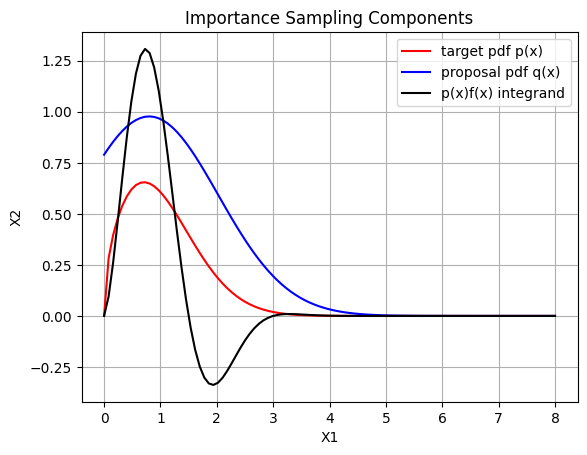

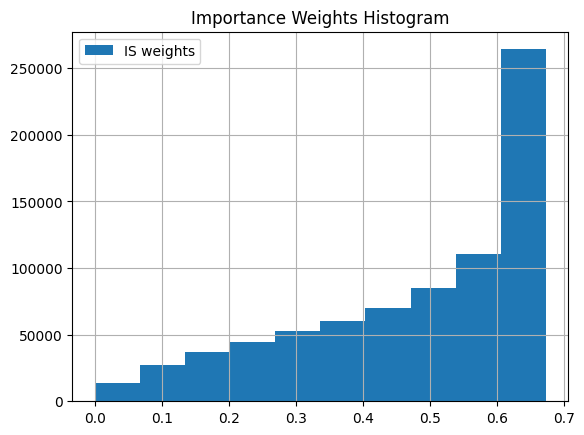

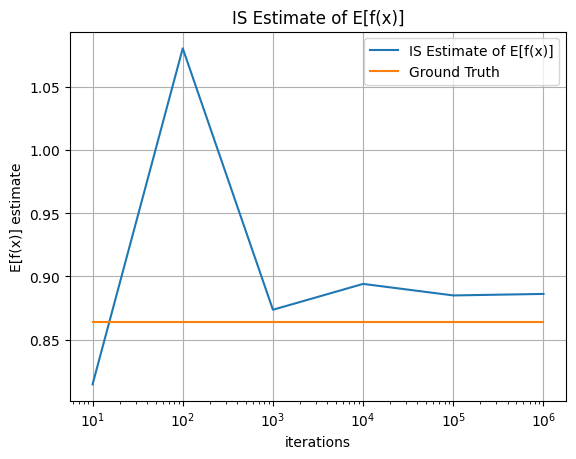

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.stats import multivariate_normal

np.random.seed(42)

class importance_sampler:

  def __init__(self, k=1.5, mu=0.8, sigma=np.sqrt(1.5), c=3):

    # Target parameters p(x)
    self.k = k

    # Proposal parameters q(x)
    self.mu = mu
    self.sigma = sigma

    # Fixes c, s.t. p(x) < c q(x)
    self.c = c
  def target_pdf(self, x):

    # p(x) ~ Chi(k=1.5)
    return (x**(self.k-1)) * np.exp(-x**2/2.0)

  def proposal_pdf(self, x):

    # q(x) ~ N(mu,sigma)
    return self.c * 1.0/np.sqrt(2*np.pi*1.5) * np.exp(-(x-self.mu)**2/(2*self.sigma**2))

  def fx(self, x):

    #Function of interest f(x), x >= 0
    return 2*np.sin((np.pi/1.5)*x)


  def sample(self, num_samples):

    # Sample from the proposal
    x = multivariate_normal.rvs(self.mu, self.sigma, num_samples)

    # Discards negative samples, since f(x) is defined for x >= 0
    idx = np.where(x >= 0)
    x_pos = x[idx]

    # Computes importance weights
    isw = self.target_pdf(x_pos) / self.proposal_pdf(x_pos)

    # Computes E[f(x)] = sum_i f(x_i) w(x_i), where x_i ~ q(x)
    fw = (isw/np.sum(isw))*self.fx(x_pos)
    f_est = np.sum(fw)

    return isw, f_est

if __name__ == "__main__":
  num_samples = [10, 100, 1000, 10000, 100000, 1000000]

  F_est_iter, IS_weights_var_iter = [], []
  for k in num_samples:
    IS = importance_sampler()
    IS_weights, F_est = IS.sample(k)
    IS_weights_var = np.var(IS_weights/np.sum(IS_weights))
    F_est_iter.append(F_est)
    IS_weights_var_iter.append(IS_weights_var)
  #ground truth (numerical integration)
  k = 1.5
  I_gt, _ = quad(lambda x: 2.0*np.sin((np.pi/1.5)*x)*(x**(k-1))*np.exp(-x**2/2.0), 0, 5)
  #generate plots
  plt.figure()
  xx = np.linspace(0,8,100)
  plt.plot(xx, IS.target_pdf(xx), '-r', label='target pdf p(x)')
  plt.plot(xx, IS.proposal_pdf(xx), '-b', label='proposal pdf q(x)')
  plt.plot(xx, IS.fx(xx) * IS.target_pdf(xx), '-k', label='p(x)f(x) integrand')
  plt.grid(True); plt.legend(); plt.xlabel("X1"); plt.ylabel("X2")
  plt.title("Importance Sampling Components")
  plt.show()
  plt.figure()
  plt.hist(IS_weights, label = "IS weights")
  plt.grid(True); plt.legend();
  plt.title("Importance Weights Histogram")
  plt.show()
  plt.figure()
  plt.semilogx(num_samples, F_est_iter, label = "IS Estimate of E[f(x)]")
  plt.semilogx(num_samples, I_gt*np.ones(len(num_samples)), label = "Ground Truth")
  plt.grid(True); plt.legend(); plt.xlabel('iterations'); plt.ylabel("E[f(x)] estimate")
  plt.title("IS Estimate of E[f(x)]")
  plt.show()

# Variational Inference: KL Divergence and the ELBO


In Bayesian inference we always want the posterior distribution $p(z|x)$ — the distribution
over hidden variables $z$ given observed data $x$. By Bayes' theorem:

$$p(z|x) = \frac{p(x|z)\,p(z)}{p(x)}, \qquad p(x) = \int p(x|z)p(z)\,dz$$

The numerator is computable. The denominator $p(x)$ requires integrating over every
possible value of $z$ — intractable in high dimensions.

**Variational Inference converts this integration problem into an optimization problem.**
Instead of computing the posterior exactly, we pick the closest approximation from a
family of distributions we can actually work with. To measure "closest", we use KL divergence.

## KL Divergence — Measuring Distance Between Distributions

### The Reverse KL

$$KL(q\|p) = \sum_x q(x) \log \frac{q(x)}{p(x)}$$

Unpacked:

- $q(x)$ — our approximating distribution, the one we choose and control
- $p(x)$ — the true target posterior, the one we want but cannot sample from directly
- $\log \frac{q(x)}{p(x)}$ — log ratio of how much probability our guess assigns to $x$
  versus how much the truth assigns. If $q(x) = p(x)$ at every $x$, this ratio is 1
  and $\log(1) = 0$
- $\sum_x q(x)[\cdots]$ — we weight each contribution by how likely $x$ is under our guess

**Three properties that matter:**
- $KL(q\|p) \geq 0$ always — proven by Jensen's inequality applied to the convex $-\log$
- $KL(q\|p) = 0$ if and only if $q = p$ everywhere — zero means perfect match
- $KL(q\|p) \neq KL(p\|q)$ — asymmetric, and this asymmetry has deep consequences

### Computing KL Between Two Gaussians

Let $p(x) = \mathcal{N}(0,1)$ and $q(x) = \mathcal{N}(\mu, \sigma^2)$. Starting from the definition:

$$KL(q\|p) = \int q(x)\log q(x)\,dx - \int q(x)\log p(x)\,dx$$

**Expanding $\log p(x)$** — substituting the Gaussian formula $p(x) = \frac{1}{\sqrt{2\pi}}\exp(-\frac{1}{2}x^2)$:

$$-\int q(x)\log p(x)\,dx = -\int q(x)\left[-\frac{1}{2}\log 2\pi - \frac{1}{2}x^2\right]dx = \frac{1}{2}\log 2\pi + \frac{1}{2}E_q[x^2]$$

Since $E_q[x^2] = \text{Var}_q(x) + (E_q[x])^2 = \sigma^2 + \mu^2$, this becomes:
$\frac{1}{2}\log 2\pi + \frac{1}{2}(\sigma^2 + \mu^2)$

**Expanding $\log q(x)$** — substituting $q(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp(-\frac{(x-\mu)^2}{2\sigma^2})$:

$$\int q(x)\log q(x)\,dx = -\frac{1}{2}\log 2\pi\sigma^2 - \frac{1}{2\sigma^2}E_q[(x-\mu)^2] = -\frac{1}{2}\log 2\pi\sigma^2 - \frac{1}{2}$$

**Combining both:**

$$KL(q\|p) = \left[\frac{1}{2}\log 2\pi + \frac{1}{2}(\sigma^2 + \mu^2)\right] + \left[-\frac{1}{2}\log 2\pi\sigma^2 - \frac{1}{2}\right] = -\frac{1}{2}\left(1 + \log\sigma^2 - \mu^2 - \sigma^2\right)$$

**Reading this result:**
- The $\mu^2$ term — KL grows quadratically as the mean drifts from zero (the target mean).
  Move the mean by 2 units, KL increases by 2. This is the parabola in Figure 3.1.
- The $\log\sigma^2 - \sigma^2$ terms — penalize both too-narrow and too-wide variance.
  Minimum at $\sigma^2 = 1$, matching the target variance exactly.
- When $\mu=0, \sigma^2=1$: KL $= -\frac{1}{2}(1 + 0 - 0 - 1) = 0$ — perfect match.

## The Variational Free Energy and ELBO

### From KL to an Optimizable Objective

We cannot minimize $KL(q\|p)$ directly because $p(x)$ requires the normalizing constant $Z$.
Let $\tilde{p}(x) = p(x)Z$ be the unnormalized distribution we can compute. Then:

$$J(q) = KL(q\|\tilde{p}) = \sum_x q(x)\log\frac{q(x)}{\tilde{p}(x)} = \sum_x q(x)\log\frac{q(x)}{p(x)Z}$$

Expanding the log of a product:

$$= \sum_x q(x)\log\frac{q(x)}{p(x)} + \sum_x q(x)\log\frac{1}{Z} = KL(q\|p) - \log Z$$

**$J(q)$ only requires $\tilde{p}(x)$ — the thing we can compute. $Z$ is an additive constant
that does not affect the optimization.**

### $J(q)$ is an Upper Bound on the Negative Log Evidence

Since $KL(q\|p) \geq 0$:

$$J(q) = KL(q\|p) - \log Z \geq -\log Z = -\log p(D)$$

Minimizing $J(q)$ from above tightens this bound. When $q = p(x|D)$ exactly, $KL = 0$ and
$J(q) = -\log p(D)$ — the bound is tight.

### The Variational Free Energy

The ELBO is $L(q) = -J(q)$. Writing out $J(q)$ explicitly:

$$\min_q J(q) = E_q[\log q(x)] + E_q[-\log\tilde{p}(x)] = -H(q) + E_q[E(x)]$$

- $E_q[\log q(x)] = -H(q)$ — **negative entropy of $q$**. Entropy measures spread.
  Minimizing $J$ encourages high entropy — pushes $q$ to remain broad and uncertain.
- $E_q[-\log\tilde{p}(x)] = E_q[E(x)]$ — **expected energy**. From physics: $-\log p(x)$
  is the "energy" of state $x$. Low energy = high probability. This pushes $q$ toward
  high-probability regions.

These two forces balance: energy says "concentrate on the mode", entropy says "spread out".
The optimum is neither — it is a distribution broad enough to have high entropy but
concentrated enough to cover high-probability regions. This is why VI avoids collapsing
to a single point unlike the MAP estimator.

## Forward vs. Reverse KL — The Asymmetry That Changes Everything

### Reverse KL: $KL(q\|p)$ — Mode-Seeking

$$KL(q\|p) = \int q(x)\log\frac{q(x)}{p(x)}\,dx$$

Ask: what happens when $p(x) = 0$ but $q(x) > 0$?
The ratio $q(x)/p(x) \to \infty$, so $\log(q/p) \to \infty$, and $q(x) \cdot \infty = \infty$.

**Reverse KL is infinite if $q$ assigns probability anywhere $p$ is zero.**
To keep KL finite, $q$ is forced to zero wherever $p$ is zero — it locks onto one mode
and ignores all others. This is called **zero-forcing** or **mode-seeking**.

### Forward KL: $KL(p\|q)$ — Mean-Seeking

$$KL(p\|q) = \int p(x)\log\frac{p(x)}{q(x)}\,dx$$

Now: what happens when $q(x) = 0$ but $p(x) > 0$?
The ratio $p(x)/q(x) \to \infty$ — forward KL is infinite.

**Forward KL is infinite if $q$ assigns zero probability anywhere $p$ has mass.**
$q$ is forced to cover all regions where $p$ is non-zero — it spreads to cover all modes.
This is called **zero-avoiding** or **mean-seeking**.

**The practical consequence:**

| | Reverse KL $KL(q\|p)$ | Forward KL $KL(p\|q)$ |
|---|---|---|
| Behavior | Locks onto one mode | Covers all modes |
| Risk | Misses other modes entirely | Sits in low-density regions between modes |
| Used in | Variational Inference | Expectation Propagation |

For a 4-mode Gaussian mixture: reverse KL gives $q$ centered on one mode. Forward KL gives $q$ centered at zero — the empty space between all four
modes, averaging them.

loading data...
 running mean-field variational inference...


100%|██████████| 15/15 [00:50<00:00,  3.35s/it]


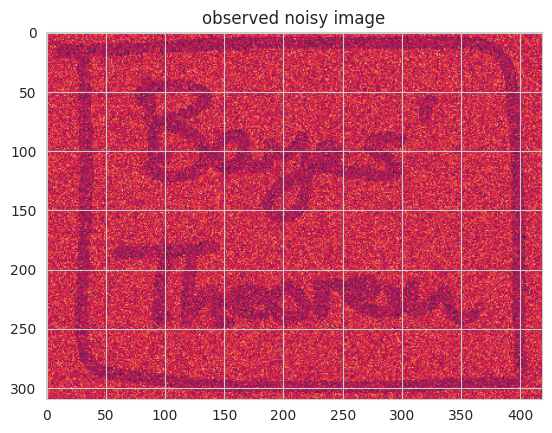

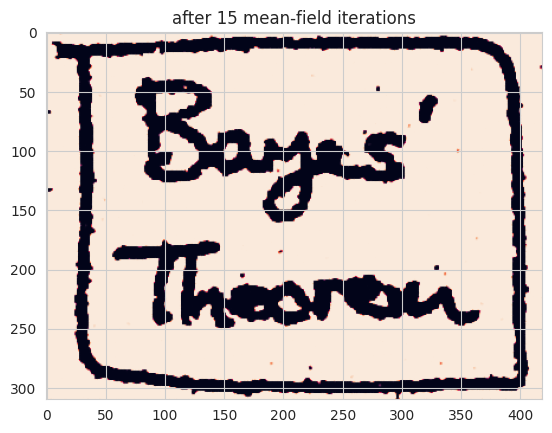

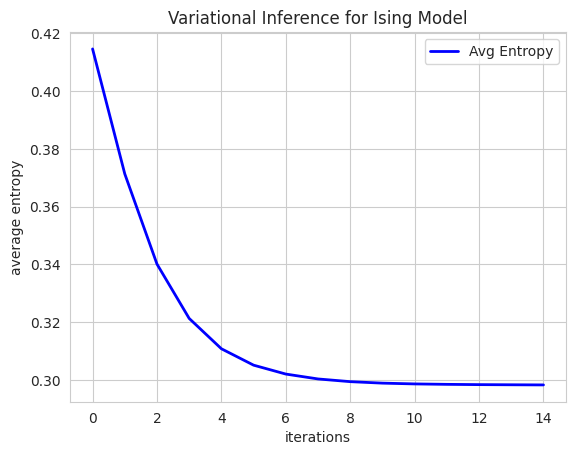

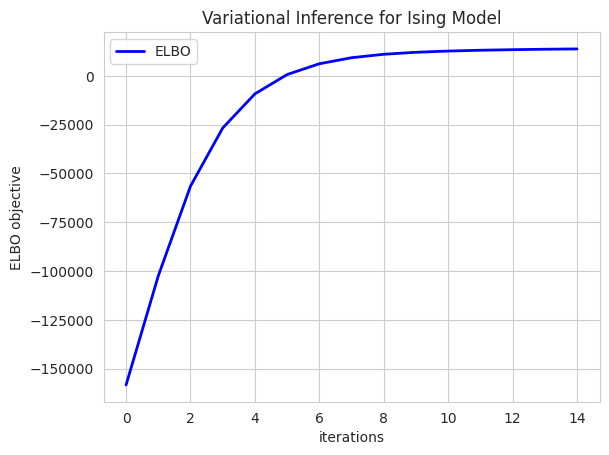

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from tqdm import tqdm
from scipy.special import expit as sigmoid
from scipy.stats import multivariate_normal

np.random.seed(42)
sns.set_style('whitegrid')

class image_denoising:

  def __init__(self, img_binary, M, N, sigma = 2, J = 1):

    # mean-field parameters
    self.sigma = sigma # noisy level
    self.M = M
    self.N = N
    self.y = img_binary + self.sigma*np.random.randn(self.M, self.N) # y_i ~ N(x_i; sigma^2);

    # Coupling strength (wij)
    self.J = J
    self.rate = 0.5
    self.max_iter = 15
    self.ELBO = np.zeros(self.max_iter)
    self.Hx_mean = np.zeros(self.max_iter) # Initialize Hx_mean

  def mean_field(self):

    # Mean-Field VI
    print(" running mean-field variational inference...")
    logodds = multivariate_normal.logpdf(self.y.flatten(), mean = +1, cov = self.sigma**2) - \
    multivariate_normal.logpdf(self.y.flatten(), mean = -1, cov = self.sigma**2)
    logodds = np.reshape(logodds, (self.M, self.N))

    # init
    p1 = sigmoid(logodds)
    mu = 2*p1-1 # Initial value of mu
    a = mu + 0.5 * logodds
    qxp1 = sigmoid(+2*a) #q_i(x_i=+1)
    qxm1 = sigmoid(-2*a) #q_i(x_i=-1)

    logp1 = np.reshape(multivariate_normal.logpdf(self.y.flatten(), mean=+1, cov=self.sigma**2), (self.M, self.N))
    logm1 = np.reshape(multivariate_normal.logpdf(self.y.flatten(), mean=-1, cov=self.sigma**2), (self.M, self.N))

    for i in tqdm(range(self.max_iter)):
      muNew = mu
      for ix in range(self.N):
        for iy in range(self.M):
          pos = iy + self.M*ix
          neighborhood = pos + np.array([-1,1,-self.M,self.M])
          boundary_idx = [iy!=0,iy!=self.M-1,ix!=0,ix!=self.N-1]
          neighborhood = neighborhood[np.where(boundary_idx)[0]]
          xx, yy = np.unravel_index(pos, (self.M,self.N), order='F')
          nx, ny = np.unravel_index(neighborhood, (self.M,self.N), order='F')

          Sbar = self.J*np.sum(mu[nx,ny])
          muNew[xx,yy] = (1-self.rate)*muNew[xx,yy] + self.rate*np.tanh(Sbar + 0.5*logodds[xx,yy])
          self.ELBO[i] = self.ELBO[i] + 0.5*(Sbar * muNew[xx,yy])
        #end for
      #end for
      mu = muNew

      a = mu + 0.5 * logodds
      qxp1 = sigmoid(+2*a) #q_i(x_i=+1)
      qxm1 = sigmoid(-2*a) #q_i(x_i=-1)
      Hx = -qxm1*np.log(qxm1+1e-10) - qxp1*np.log(qxp1+1e-10) #entropy

      self.ELBO[i] = self.ELBO[i] + np.sum(qxp1*logp1 + qxm1*logm1) + np.sum(Hx)
      self.Hx_mean[i] = np.mean(Hx)
    #end for
    return mu

if __name__ == "__main__":

  #load data
  print("loading data...")
  data = Image.open('/bayes.bmp')
  img = np.double(data)
  img_mean = np.mean(img)
  img_binary = +1*(img>img_mean) + -1*(img<img_mean)
  [M, N] = img_binary.shape

  mrf = image_denoising(img_binary, M=M, N=N, sigma=2, J=1)
  mu = mrf.mean_field()

  #generate plots
  plt.figure()
  plt.imshow(mrf.y)
  plt.title("observed noisy image")
  plt.show()

  plt.figure()
  plt.imshow(mu)
  plt.title("after %d mean-field iterations" %mrf.max_iter)
  plt.show()

  plt.figure()
  plt.plot(mrf.Hx_mean, color='b', lw=2.0, label='Avg Entropy')
  plt.title('Variational Inference for Ising Model')
  plt.xlabel('iterations'); plt.ylabel('average entropy')
  plt.legend(loc='upper right')
  plt.show()

  plt.figure()
  plt.plot(mrf.ELBO, color='b', lw=2.0, label='ELBO')
  plt.title('Variational Inference for Ising Model')
  plt.xlabel('iterations'); plt.ylabel('ELBO objective')
  plt.legend(loc='upper left')
  plt.show()